# Seminário 1 — Eixo A: Profundidade e Largura da Rede
### Comparativo de Arquiteturas DNN em Benchmarks Clássicos
### Modalidade 1 — Experimentos Próprios

---

**Disciplina:** Mineração de Dados (Tópicos Especiais em IA)  
**Professor:** Adam D. F. dos Santos — UNIFESSPA  
**Datasets:** MNIST e Fashion-MNIST  

---

**Pergunta orientadora:**  
> *Mais camadas ou mais neurônios por camada, o que importa mais? A partir de qual profundidade o ganho marginal desaparece no MNIST e no Fashion-MNIST?*

---

### Experimentos planejados

| Série | Variável | Configurações |
|-------|----------|---------------|
| **Profundidade** (largura fixa = 256) | Camadas ocultas | 1, 2, 3, 5, 7 |
| **Largura** (profundidade fixa = 3) | Neurônios/camada | 64, 128, 256, 512, 1024 |

**Métricas:** Acurácia no teste, tempo de treino por época, número total de parâmetros

---
## 1. Configuração e Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import time

# Verificar se GPU está disponível
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo em uso: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')


# REPRODUTIBILIDADE (configuração obrigatória)
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True

print('\nConfiguração base do seminário:')
print('  Batch size  : 64')
print('  Épocas      : 15')
print('  Otimizador  : Adam (lr=1e-3)')
print('  Ativação    : ReLU')
print('  Regularização: Nenhuma')
print('  Seed        : 42')

Dispositivo em uso: cuda
GPU: Tesla T4

Configuração base do seminário:
  Batch size  : 64
  Épocas      : 15
  Otimizador  : Adam (lr=1e-3)
  Ativação    : ReLU
  Regularização: Nenhuma
  Seed        : 42


---
## 2. Carregamento dos Dados (MNIST e Fashion-MNIST)

In [ ]:
# MNIST
transform_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_mnist = datasets.MNIST(root='./data', train=True,  download=True, transform=transform_mnist)
test_mnist  = datasets.MNIST(root='./data', train=False, download=True, transform=transform_mnist)

train_loader_mnist = DataLoader(train_mnist, batch_size=64, shuffle=True)
test_loader_mnist  = DataLoader(test_mnist,  batch_size=64, shuffle=False)

print(f'MNIST — Treino: {len(train_mnist)} | Teste: {len(test_mnist)}')

# Fashion-MNIST
transform_fmnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

train_fmnist = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform_fmnist)
test_fmnist  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform_fmnist)

train_loader_fmnist = DataLoader(train_fmnist, batch_size=64, shuffle=True)
test_loader_fmnist  = DataLoader(test_fmnist,  batch_size=64, shuffle=False)

print(f'Fashion-MNIST — Treino: {len(train_fmnist)} | Teste: {len(test_fmnist)}')

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.96MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.0MB/s]


MNIST — Treino: 60000 | Teste: 10000


100%|██████████| 26.4M/26.4M [00:02<00:00, 10.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 172kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.19MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.3MB/s]

Fashion-MNIST — Treino: 60000 | Teste: 10000


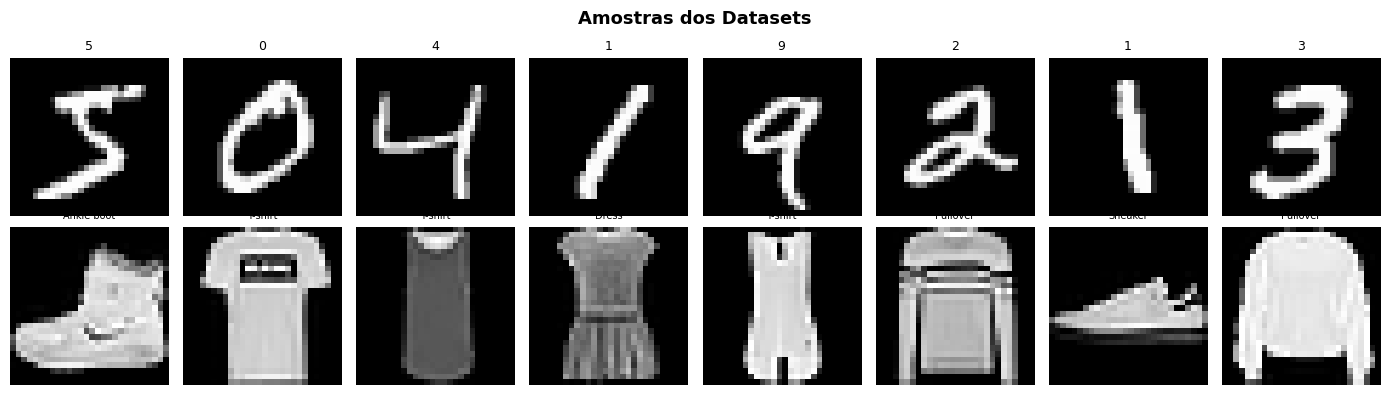

In [3]:
# Visualizar amostras dos dois datasets
fig, axes = plt.subplots(2, 8, figsize=(14, 4))

# MNIST
for i in range(8):
    img, label = train_mnist[i]
    axes[0, i].imshow(img.squeeze(), cmap='gray')
    axes[0, i].set_title(f'{label}', fontsize=9)
    axes[0, i].axis('off')

# Fashion-MNIST
classes_fmnist = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
                  'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
for i in range(8):
    img, label = train_fmnist[i]
    img_show = img.squeeze() * 0.3530 + 0.2860
    axes[1, i].imshow(img_show.clamp(0, 1), cmap='gray')
    axes[1, i].set_title(f'{classes_fmnist[label]}', fontsize=7)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('MNIST', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('F-MNIST', fontsize=11, fontweight='bold')
plt.suptitle('Amostras dos Datasets', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Definição do Modelo DNN e Funções Auxiliares

Modelo parametrizável que aceita qualquer lista de camadas ocultas. Adaptado do notebook da prática.

In [ ]:
# CLASSE DNN PARAMETRIZÁVEL

class DNN(nn.Module):
    def __init__(self, n_entradas=784, n_classes=10,
                 camadas_ocultas=[256, 256, 256],
                 ativacao=nn.ReLU):
        super(DNN, self).__init__()

        layers = []
        dim_anterior = n_entradas

        for dim in camadas_ocultas:
            layers.append(nn.Linear(dim_anterior, dim))
            layers.append(ativacao())
            dim_anterior = dim

        layers.append(nn.Linear(dim_anterior, n_classes))
        self.rede = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten: (batch, 1, 28, 28) → (batch, 784)
        return self.rede(x)


def contar_parametros(modelo):
    """Retorna o número total de parâmetros treináveis."""
    return sum(p.numel() for p in modelo.parameters() if p.requires_grad)


# Teste rápido
modelo_teste = DNN(camadas_ocultas=[256, 256, 256])
print(f'Modelo baseline (3 x 256): {contar_parametros(modelo_teste):,} parâmetros')
print(modelo_teste)

Modelo baseline (3 x 256): 335,114 parâmetros
DNN(
  (rede): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [ ]:
# FUNÇÕES DE TREINO E AVALIAÇÃO

def treinar(modelo, loader, otimizador, criterio, device):
    """Executa uma época de treino. Retorna (perda_média, acurácia)."""
    modelo.train()
    perda_total, corretos = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        otimizador.zero_grad()
        saidas = modelo(imgs)
        perda = criterio(saidas, labels)
        perda.backward()
        otimizador.step()
        perda_total += perda.item() * imgs.size(0)
        corretos += (saidas.argmax(1) == labels).sum().item()
    n = len(loader.dataset)
    return perda_total / n, corretos / n


def avaliar(modelo, loader, criterio, device):
    """Avalia o modelo no conjunto de teste. Retorna (perda_média, acurácia)."""
    modelo.eval()
    perda_total, corretos = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            saidas = modelo(imgs)
            perda = criterio(saidas, labels)
            perda_total += perda.item() * imgs.size(0)
            corretos += (saidas.argmax(1) == labels).sum().item()
    n = len(loader.dataset)
    return perda_total / n, corretos / n


def executar_experimento(camadas_ocultas, train_loader, test_loader,
                         n_epochs=15, lr=1e-3, nome='Modelo'):
    """
    Executa um experimento completo: cria modelo, treina e retorna métricas.
    Reseta a seed antes de cada experimento para reprodutibilidade.
    """
    # Reset seeds para cada experimento
    torch.manual_seed(42)
    np.random.seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(42)

    modelo = DNN(camadas_ocultas=camadas_ocultas).to(device)
    criterio = nn.CrossEntropyLoss()
    otimizador = optim.Adam(modelo.parameters(), lr=lr)

    n_params = contar_parametros(modelo)
    historico = defaultdict(list)
    tempos_epoca = []

    print(f'\n{"="*60}')
    print(f'{nome} | Camadas: {camadas_ocultas} | Parâmetros: {n_params:,}')
    print(f'{"="*60}')

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        p_treino, acc_treino = treinar(modelo, train_loader, otimizador, criterio, device)
        tempo_epoca = time.time() - t0
        tempos_epoca.append(tempo_epoca)

        p_teste, acc_teste = avaliar(modelo, test_loader, criterio, device)

        historico['perda_treino'].append(p_treino)
        historico['perda_teste'].append(p_teste)
        historico['acc_treino'].append(acc_treino)
        historico['acc_teste'].append(acc_teste)

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Época {epoch:2d}/{n_epochs} | '
                  f'Loss treino: {p_treino:.4f} | '
                  f'Acc treino: {acc_treino:.4f} | '
                  f'Acc teste: {acc_teste:.4f} | '
                  f'Tempo: {tempo_epoca:.1f}s')

    resultado = {
        'nome': nome,
        'camadas': camadas_ocultas,
        'n_params': n_params,
        'acc_teste_final': historico['acc_teste'][-1],
        'acc_treino_final': historico['acc_treino'][-1],
        'tempo_medio_epoca': np.mean(tempos_epoca),
        'historico': dict(historico)
    }

    print(f'  → Acc teste final: {resultado["acc_teste_final"]:.4f} | '
          f'Tempo médio/época: {resultado["tempo_medio_epoca"]:.2f}s')

    return resultado

print('Funções definidas com sucesso!')

Funções definidas com sucesso!


---
## 4. Série 1 — Variando Profundidade (Largura fixa = 256)

Mantemos 256 neurônios por camada e variamos o número de camadas ocultas: **1, 2, 3, 5 e 7**.

A configuração baseline (3 camadas × 256) serve como ponto de referência.

In [ ]:
# SÉRIE 1 — PROFUNDIDADE (MNIST)

configs_profundidade = {
    '1 camada × 256':   [256],
    '2 camadas × 256':  [256, 256],
    '3 camadas × 256':  [256, 256, 256],           # baseline
    '5 camadas × 256':  [256]*5,
    '7 camadas × 256':  [256]*7,
}

print('╔══════════════════════════════════════════════════════════╗')
print('║   SÉRIE 1: PROFUNDIDADE — MNIST                          ║')
print('╚══════════════════════════════════════════════════════════╝')

resultados_prof_mnist = []
for nome, camadas in configs_profundidade.items():
    res = executar_experimento(camadas, train_loader_mnist, test_loader_mnist,
                               n_epochs=15, nome=f'[MNIST] {nome}')
    resultados_prof_mnist.append(res)

╔══════════════════════════════════════════════════════════╗
║   SÉRIE 1: PROFUNDIDADE — MNIST                        ║
╚══════════════════════════════════════════════════════════╝

[MNIST] 1 camada × 256 | Camadas: [256] | Parâmetros: 203,530
  Época  1/15 | Loss treino: 0.2258 | Acc treino: 0.9328 | Acc teste: 0.9625 | Tempo: 14.4s
  Época  5/15 | Loss treino: 0.0383 | Acc treino: 0.9875 | Acc teste: 0.9779 | Tempo: 14.0s
  Época 10/15 | Loss treino: 0.0174 | Acc treino: 0.9941 | Acc teste: 0.9796 | Tempo: 13.5s
  Época 15/15 | Loss treino: 0.0091 | Acc treino: 0.9968 | Acc teste: 0.9793 | Tempo: 13.4s
  → Acc teste final: 0.9793 | Tempo médio/época: 13.98s

[MNIST] 2 camadas × 256 | Camadas: [256, 256] | Parâmetros: 269,322
  Época  1/15 | Loss treino: 0.2201 | Acc treino: 0.9328 | Acc teste: 0.9627 | Tempo: 13.7s
  Época  5/15 | Loss treino: 0.0386 | Acc treino: 0.9875 | Acc teste: 0.9803 | Tempo: 13.5s
  Época 10/15 | Loss treino: 0.0207 | Acc treino: 0.9933 | Acc teste: 0.9776 | 

In [ ]:
# SÉRIE 1 — PROFUNDIDADE (Fashion-MNIST)

print('╔══════════════════════════════════════════════════════════╗')
print('║   SÉRIE 1: PROFUNDIDADE — Fashion-MNIST                ║')
print('╚══════════════════════════════════════════════════════════╝')

resultados_prof_fmnist = []
for nome, camadas in configs_profundidade.items():
    res = executar_experimento(camadas, train_loader_fmnist, test_loader_fmnist,
                               n_epochs=15, nome=f'[F-MNIST] {nome}')
    resultados_prof_fmnist.append(res)

╔══════════════════════════════════════════════════════════╗
║   SÉRIE 1: PROFUNDIDADE — Fashion-MNIST                ║
╚══════════════════════════════════════════════════════════╝

[F-MNIST] 1 camada × 256 | Camadas: [256] | Parâmetros: 203,530
  Época  1/15 | Loss treino: 0.4520 | Acc treino: 0.8362 | Acc teste: 0.8521 | Tempo: 13.4s
  Época  5/15 | Loss treino: 0.2629 | Acc treino: 0.9021 | Acc teste: 0.8795 | Tempo: 13.4s
  Época 10/15 | Loss treino: 0.2030 | Acc treino: 0.9236 | Acc teste: 0.8808 | Tempo: 13.8s
  Época 15/15 | Loss treino: 0.1624 | Acc treino: 0.9387 | Acc teste: 0.8895 | Tempo: 13.7s
  → Acc teste final: 0.8895 | Tempo médio/época: 13.68s

[F-MNIST] 2 camadas × 256 | Camadas: [256, 256] | Parâmetros: 269,322
  Época  1/15 | Loss treino: 0.4553 | Acc treino: 0.8341 | Acc teste: 0.8497 | Tempo: 13.7s
  Época  5/15 | Loss treino: 0.2630 | Acc treino: 0.9003 | Acc teste: 0.8816 | Tempo: 13.7s
  Época 10/15 | Loss treino: 0.1949 | Acc treino: 0.9249 | Acc teste: 0.889

---
## 5. Série 2 — Variando Largura (Profundidade fixa = 3 camadas)

Mantemos 3 camadas ocultas e variamos o número de neurônios por camada: **64, 128, 256, 512 e 1024**.

In [ ]:
# SÉRIE 2 — LARGURA (MNIST)

configs_largura = {
    '3 camadas × 64':    [64, 64, 64],
    '3 camadas × 128':   [128, 128, 128],
    '3 camadas × 256':   [256, 256, 256],           # baseline (mesmo da Série 1)
    '3 camadas × 512':   [512, 512, 512],
    '3 camadas × 1024':  [1024, 1024, 1024],
}

print('╔══════════════════════════════════════════════════════════╗')
print('║   SÉRIE 2: LARGURA — MNIST                               ║')
print('╚══════════════════════════════════════════════════════════╝')

resultados_larg_mnist = []
for nome, camadas in configs_largura.items():
    res = executar_experimento(camadas, train_loader_mnist, test_loader_mnist,
                               n_epochs=15, nome=f'[MNIST] {nome}')
    resultados_larg_mnist.append(res)

╔══════════════════════════════════════════════════════════╗
║   SÉRIE 2: LARGURA — MNIST                               ║
╚══════════════════════════════════════════════════════════╝

[MNIST] 3 camadas × 64 | Camadas: [64, 64, 64] | Parâmetros: 59,210
  Época  1/15 | Loss treino: 0.3197 | Acc treino: 0.9033 | Acc teste: 0.9489 | Tempo: 14.3s
  Época  5/15 | Loss treino: 0.0720 | Acc treino: 0.9775 | Acc teste: 0.9715 | Tempo: 14.2s
  Época 10/15 | Loss treino: 0.0369 | Acc treino: 0.9881 | Acc teste: 0.9732 | Tempo: 13.9s
  Época 15/15 | Loss treino: 0.0224 | Acc treino: 0.9923 | Acc teste: 0.9756 | Tempo: 13.6s
  → Acc teste final: 0.9756 | Tempo médio/época: 13.87s

[MNIST] 3 camadas × 128 | Camadas: [128, 128, 128] | Parâmetros: 134,794
  Época  1/15 | Loss treino: 0.2689 | Acc treino: 0.9189 | Acc teste: 0.9542 | Tempo: 13.9s
  Época  5/15 | Loss treino: 0.0529 | Acc treino: 0.9829 | Acc teste: 0.9758 | Tempo: 14.0s
  Época 10/15 | Loss treino: 0.0288 | Acc treino: 0.9905 | Acc tes

In [ ]:
# SÉRIE 2 — LARGURA (Fashion-MNIST)

print('╔══════════════════════════════════════════════════════════╗')
print('║   SÉRIE 2: LARGURA — Fashion-MNIST                       ║')
print('╚══════════════════════════════════════════════════════════╝')

resultados_larg_fmnist = []
for nome, camadas in configs_largura.items():
    res = executar_experimento(camadas, train_loader_fmnist, test_loader_fmnist,
                               n_epochs=15, nome=f'[F-MNIST] {nome}')
    resultados_larg_fmnist.append(res)

╔══════════════════════════════════════════════════════════╗
║   SÉRIE 2: LARGURA — Fashion-MNIST                       ║
╚══════════════════════════════════════════════════════════╝

[F-MNIST] 3 camadas × 64 | Camadas: [64, 64, 64] | Parâmetros: 59,210
  Época  1/15 | Loss treino: 0.5157 | Acc treino: 0.8130 | Acc teste: 0.8328 | Tempo: 13.7s
  Época  5/15 | Loss treino: 0.2944 | Acc treino: 0.8920 | Acc teste: 0.8766 | Tempo: 14.1s
  Época 10/15 | Loss treino: 0.2368 | Acc treino: 0.9113 | Acc teste: 0.8733 | Tempo: 13.9s
  Época 15/15 | Loss treino: 0.2037 | Acc treino: 0.9223 | Acc teste: 0.8818 | Tempo: 13.9s
  → Acc teste final: 0.8818 | Tempo médio/época: 13.96s

[F-MNIST] 3 camadas × 128 | Camadas: [128, 128, 128] | Parâmetros: 134,794
  Época  1/15 | Loss treino: 0.4851 | Acc treino: 0.8228 | Acc teste: 0.8365 | Tempo: 14.0s
  Época  5/15 | Loss treino: 0.2798 | Acc treino: 0.8952 | Acc teste: 0.8770 | Tempo: 14.0s
  Época 10/15 | Loss treino: 0.2162 | Acc treino: 0.9184 | Acc

---
## 6. Tabelas Comparativas de Resultados

Consolidação de todos os resultados em tabelas formatadas para a Ficha Comparativa.

In [ ]:
# TABELA 1: PROFUNDIDADE

dados_prof = []
for res_m, res_f in zip(resultados_prof_mnist, resultados_prof_fmnist):
    dados_prof.append({
        'Configuração': res_m['nome'].replace('[MNIST] ', ''),
        '# Parâmetros': f"{res_m['n_params']:,}",
        'MNIST Acc (%)': f"{res_m['acc_teste_final']*100:.2f}",
        'F-MNIST Acc (%)': f"{res_f['acc_teste_final']*100:.2f}",
        'Tempo/época (s)': f"{res_m['tempo_medio_epoca']:.2f}",
    })

df_prof = pd.DataFrame(dados_prof)
print('=' * 80)
print('TABELA 1 — Variação de Profundidade (largura fixa = 256)')
print('=' * 80)
print(df_prof.to_string(index=False))
print()

# TABELA 2: LARGURA

dados_larg = []
for res_m, res_f in zip(resultados_larg_mnist, resultados_larg_fmnist):
    dados_larg.append({
        'Configuração': res_m['nome'].replace('[MNIST] ', ''),
        '# Parâmetros': f"{res_m['n_params']:,}",
        'MNIST Acc (%)': f"{res_m['acc_teste_final']*100:.2f}",
        'F-MNIST Acc (%)': f"{res_f['acc_teste_final']*100:.2f}",
        'Tempo/época (s)': f"{res_m['tempo_medio_epoca']:.2f}",
    })

df_larg = pd.DataFrame(dados_larg)
print('=' * 80)
print('TABELA 2 — Variação de Largura (profundidade fixa = 3 camadas)')
print('=' * 80)
print(df_larg.to_string(index=False))
print()

# TABELA COMPLETA UNIFICADA (para a Ficha Comparativa)

print('=' * 80)
print('TABELA COMPLETA — Todos os Experimentos do Eixo A')
print('=' * 80)

todos_resultados = []
for res_m, res_f in zip(resultados_prof_mnist, resultados_prof_fmnist):
    obs = 'baseline' if '3 camadas × 256' in res_m['nome'] else ''
    todos_resultados.append({
        'Configuração': res_m['nome'].replace('[MNIST] ', ''),
        '# Parâmetros': f"{res_m['n_params']:,}",
        'MNIST Acc (%)': f"{res_m['acc_teste_final']*100:.2f}",
        'F-MNIST Acc (%)': f"{res_f['acc_teste_final']*100:.2f}",
        'Tempo/época (s)': f"{res_m['tempo_medio_epoca']:.2f}",
        'Observação': obs
    })

# Adicionar larguras (excluindo 3x256 que já aparece na profundidade)
for res_m, res_f in zip(resultados_larg_mnist, resultados_larg_fmnist):
    if '3 camadas × 256' in res_m['nome']:
        continue  # já incluído acima
    obs = ''
    if '64' in res_m['nome']:
        obs = 'largura reduzida'
    elif '128' in res_m['nome']:
        obs = 'largura reduzida'
    elif '512' in res_m['nome']:
        obs = 'largura aumentada'
    elif '1024' in res_m['nome']:
        obs = 'largura máxima'
    todos_resultados.append({
        'Configuração': res_m['nome'].replace('[MNIST] ', ''),
        '# Parâmetros': f"{res_m['n_params']:,}",
        'MNIST Acc (%)': f"{res_m['acc_teste_final']*100:.2f}",
        'F-MNIST Acc (%)': f"{res_f['acc_teste_final']*100:.2f}",
        'Tempo/época (s)': f"{res_m['tempo_medio_epoca']:.2f}",
        'Observação': obs
    })

df_completa = pd.DataFrame(todos_resultados)
print(df_completa.to_string(index=False))

TABELA 1 — Variação de Profundidade (largura fixa = 256)
   Configuração # Parâmetros MNIST Acc (%) F-MNIST Acc (%) Tempo/época (s)
 1 camada × 256      203,530         97.93           88.95           13.98
2 camadas × 256      269,322         97.21           89.07           13.83
3 camadas × 256      335,114         97.71           88.59           13.93
5 camadas × 256      466,698         98.04           88.33           14.54
7 camadas × 256      598,282         97.03           88.55           14.72

TABELA 2 — Variação de Largura (profundidade fixa = 3 camadas)
    Configuração # Parâmetros MNIST Acc (%) F-MNIST Acc (%) Tempo/época (s)
  3 camadas × 64       59,210         97.56           88.18           13.87
 3 camadas × 128      134,794         97.74           88.51           13.92
 3 camadas × 256      335,114         97.71           88.59           14.09
 3 camadas × 512      932,362         97.76           88.81           14.10
3 camadas × 1024    2,913,290         97.97      

---
## 7. Gráficos Comparativos

### 7.1 Acurácia vs Profundidade (MNIST e Fashion-MNIST)

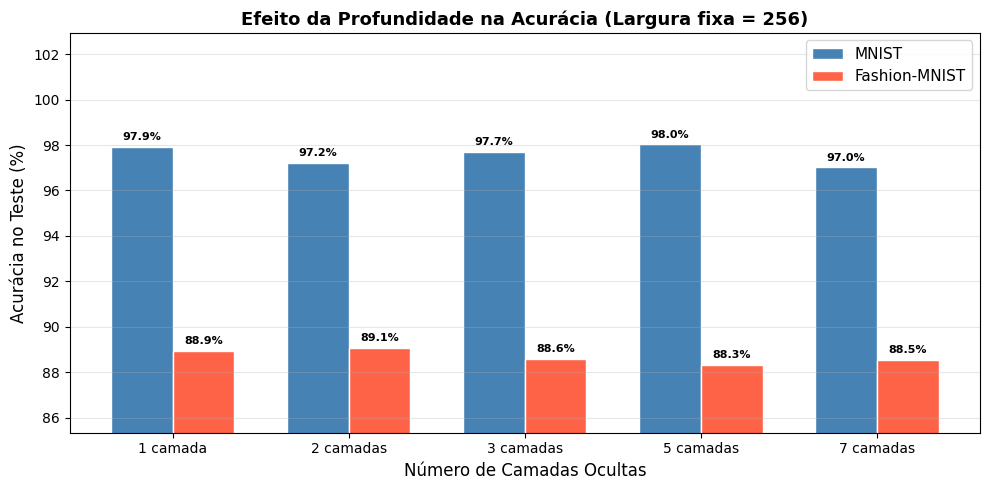

Gráfico salvo: grafico_profundidade_acuracia.png


In [ ]:
# GRÁFICO 1: Acurácia vs Profundidade (barras agrupadas)

profundidades = [1, 2, 3, 5, 7]
acc_prof_mnist  = [r['acc_teste_final'] * 100 for r in resultados_prof_mnist]
acc_prof_fmnist = [r['acc_teste_final'] * 100 for r in resultados_prof_fmnist]

x = np.arange(len(profundidades))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, acc_prof_mnist,  width, label='MNIST', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, acc_prof_fmnist, width, label='Fashion-MNIST', color='tomato', edgecolor='white')

# Adicionar valores nas barras
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Número de Camadas Ocultas', fontsize=12)
ax.set_ylabel('Acurácia no Teste (%)', fontsize=12)
ax.set_title('Efeito da Profundidade na Acurácia (Largura fixa = 256)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{p} camada{"s" if p > 1 else ""}' for p in profundidades])
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(bottom=min(min(acc_prof_mnist), min(acc_prof_fmnist)) - 3)

plt.tight_layout()
plt.savefig('grafico_profundidade_acuracia.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: grafico_profundidade_acuracia.png')

### 7.2 Acurácia vs Largura (MNIST e Fashion-MNIST)

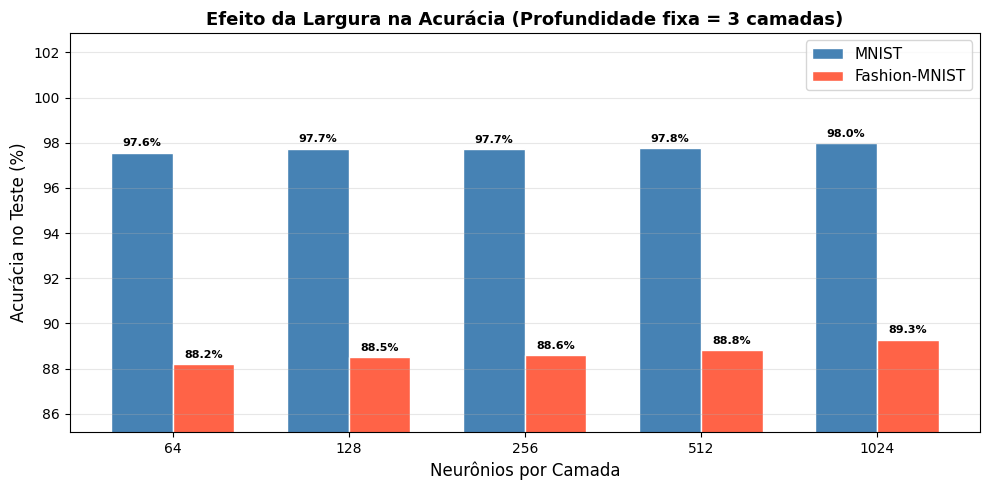

Gráfico salvo: grafico_largura_acuracia.png


In [ ]:
# GRÁFICO 2: Acurácia vs Largura (barras agrupadas)

larguras = [64, 128, 256, 512, 1024]
acc_larg_mnist  = [r['acc_teste_final'] * 100 for r in resultados_larg_mnist]
acc_larg_fmnist = [r['acc_teste_final'] * 100 for r in resultados_larg_fmnist]

x = np.arange(len(larguras))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, acc_larg_mnist,  width, label='MNIST', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, acc_larg_fmnist, width, label='Fashion-MNIST', color='tomato', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Neurônios por Camada', fontsize=12)
ax.set_ylabel('Acurácia no Teste (%)', fontsize=12)
ax.set_title('Efeito da Largura na Acurácia (Profundidade fixa = 3 camadas)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([str(l) for l in larguras])
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(bottom=min(min(acc_larg_mnist), min(acc_larg_fmnist)) - 3)

plt.tight_layout()
plt.savefig('grafico_largura_acuracia.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: grafico_largura_acuracia.png')

### 7.3 Curvas de Aprendizado — Profundidade

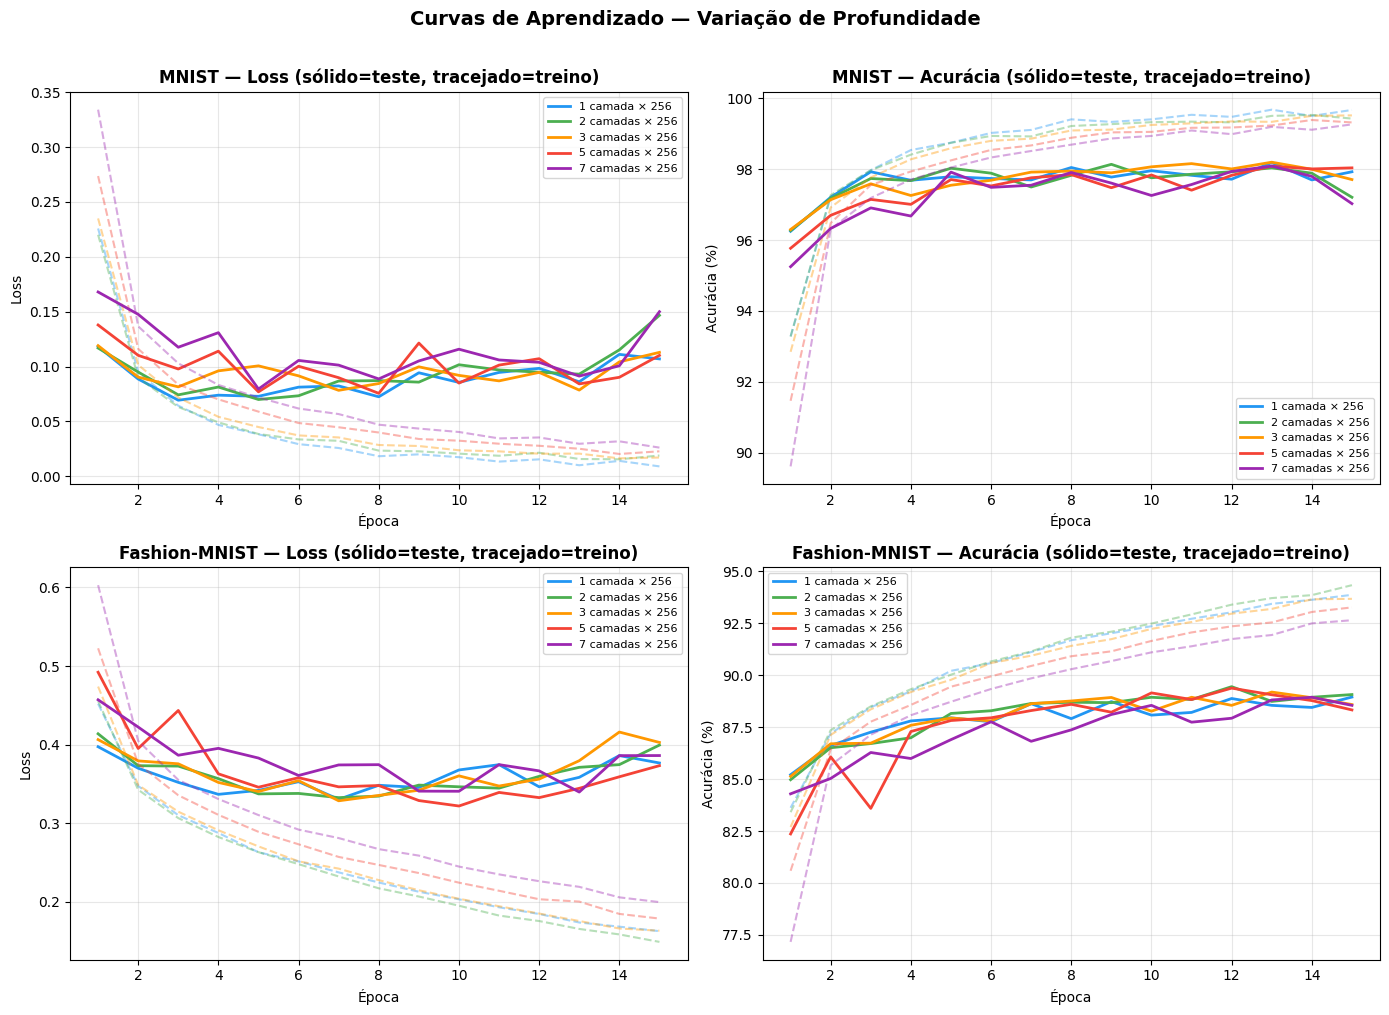

Gráfico salvo: grafico_curvas_profundidade.png


In [ ]:
# GRÁFICO 3: Curvas de aprendizado — Profundidade

cores = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
nomes_prof = list(configs_profundidade.keys())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# MNIST: Loss 
ax = axes[0, 0]
for i, res in enumerate(resultados_prof_mnist):
    epochs = range(1, 16)
    ax.plot(epochs, res['historico']['perda_treino'], '--', color=cores[i], alpha=0.4)
    ax.plot(epochs, res['historico']['perda_teste'],  '-',  color=cores[i], label=nomes_prof[i], linewidth=2)
ax.set_title('MNIST — Loss (sólido=teste, tracejado=treino)', fontweight='bold')
ax.set_xlabel('Época')
ax.set_ylabel('Loss')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# MNIST: Acurácia
ax = axes[0, 1]
for i, res in enumerate(resultados_prof_mnist):
    epochs = range(1, 16)
    ax.plot(epochs, [a*100 for a in res['historico']['acc_treino']], '--', color=cores[i], alpha=0.4)
    ax.plot(epochs, [a*100 for a in res['historico']['acc_teste']],  '-',  color=cores[i], label=nomes_prof[i], linewidth=2)
ax.set_title('MNIST — Acurácia (sólido=teste, tracejado=treino)', fontweight='bold')
ax.set_xlabel('Época')
ax.set_ylabel('Acurácia (%)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Fashion-MNIST: Loss
ax = axes[1, 0]
for i, res in enumerate(resultados_prof_fmnist):
    epochs = range(1, 16)
    ax.plot(epochs, res['historico']['perda_treino'], '--', color=cores[i], alpha=0.4)
    ax.plot(epochs, res['historico']['perda_teste'],  '-',  color=cores[i], label=nomes_prof[i], linewidth=2)
ax.set_title('Fashion-MNIST — Loss (sólido=teste, tracejado=treino)', fontweight='bold')
ax.set_xlabel('Época')
ax.set_ylabel('Loss')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Fashion-MNIST: Acurácia
ax = axes[1, 1]
for i, res in enumerate(resultados_prof_fmnist):
    epochs = range(1, 16)
    ax.plot(epochs, [a*100 for a in res['historico']['acc_treino']], '--', color=cores[i], alpha=0.4)
    ax.plot(epochs, [a*100 for a in res['historico']['acc_teste']],  '-',  color=cores[i], label=nomes_prof[i], linewidth=2)
ax.set_title('Fashion-MNIST — Acurácia (sólido=teste, tracejado=treino)', fontweight='bold')
ax.set_xlabel('Época')
ax.set_ylabel('Acurácia (%)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('Curvas de Aprendizado — Variação de Profundidade', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('grafico_curvas_profundidade.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: grafico_curvas_profundidade.png')

### 7.4 Curvas de Aprendizado — Largura

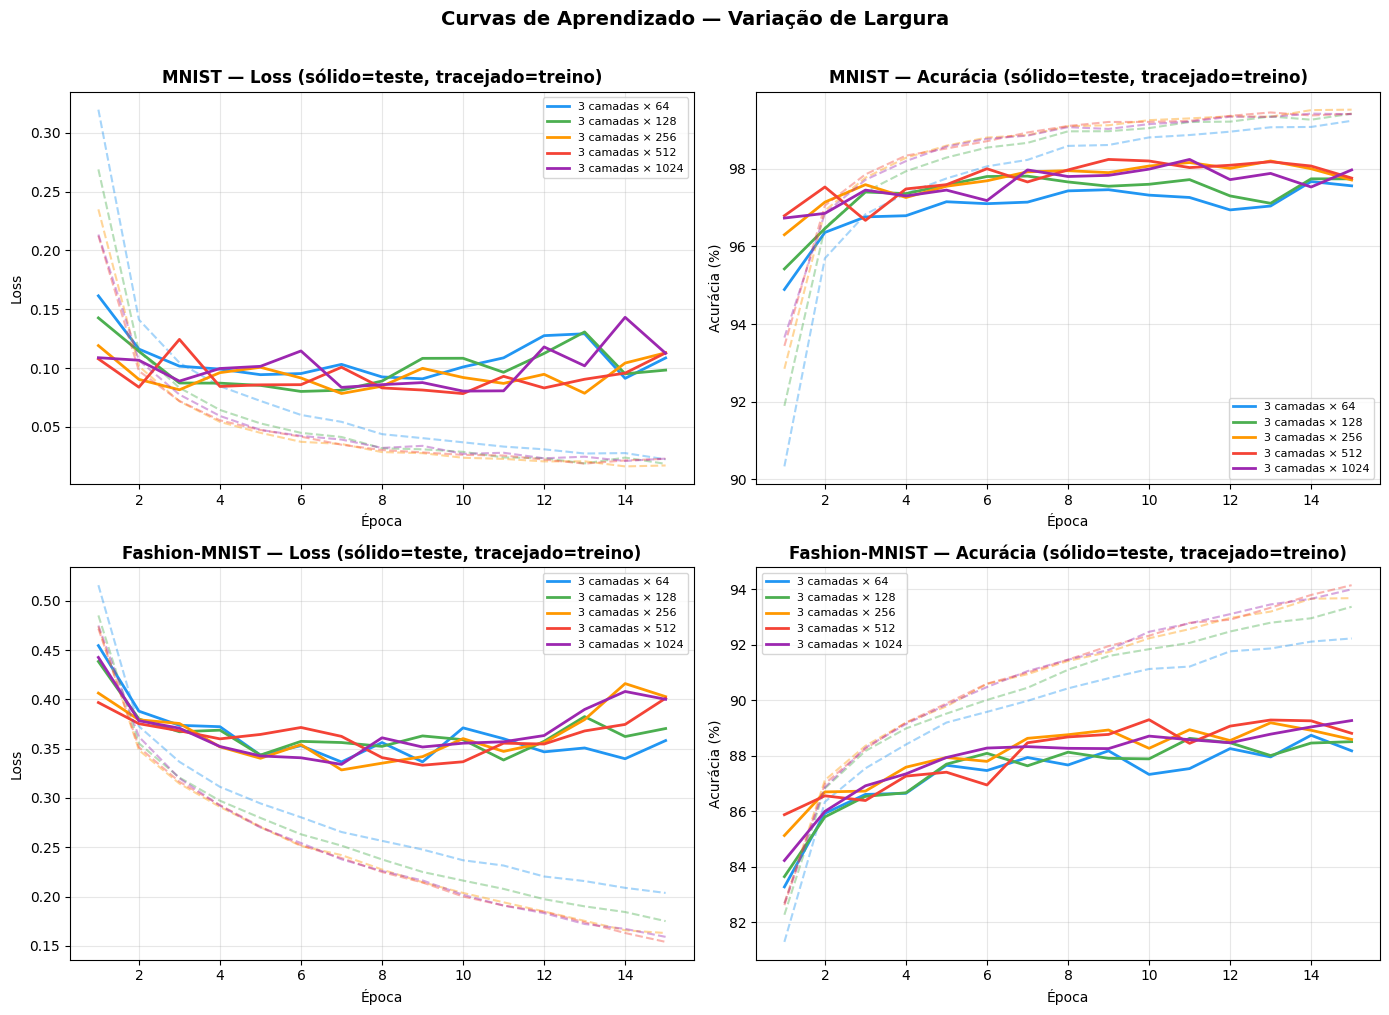

Gráfico salvo: grafico_curvas_largura.png


In [ ]:
# GRÁFICO 4: Curvas de aprendizado — Largura

nomes_larg = list(configs_largura.keys())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# MNIST: Loss
ax = axes[0, 0]
for i, res in enumerate(resultados_larg_mnist):
    epochs = range(1, 16)
    ax.plot(epochs, res['historico']['perda_treino'], '--', color=cores[i], alpha=0.4)
    ax.plot(epochs, res['historico']['perda_teste'],  '-',  color=cores[i], label=nomes_larg[i], linewidth=2)
ax.set_title('MNIST — Loss (sólido=teste, tracejado=treino)', fontweight='bold')
ax.set_xlabel('Época')
ax.set_ylabel('Loss')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# MNIST: Acurácia
ax = axes[0, 1]
for i, res in enumerate(resultados_larg_mnist):
    epochs = range(1, 16)
    ax.plot(epochs, [a*100 for a in res['historico']['acc_treino']], '--', color=cores[i], alpha=0.4)
    ax.plot(epochs, [a*100 for a in res['historico']['acc_teste']],  '-',  color=cores[i], label=nomes_larg[i], linewidth=2)
ax.set_title('MNIST — Acurácia (sólido=teste, tracejado=treino)', fontweight='bold')
ax.set_xlabel('Época')
ax.set_ylabel('Acurácia (%)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Fashion-MNIST: Loss
ax = axes[1, 0]
for i, res in enumerate(resultados_larg_fmnist):
    epochs = range(1, 16)
    ax.plot(epochs, res['historico']['perda_treino'], '--', color=cores[i], alpha=0.4)
    ax.plot(epochs, res['historico']['perda_teste'],  '-',  color=cores[i], label=nomes_larg[i], linewidth=2)
ax.set_title('Fashion-MNIST — Loss (sólido=teste, tracejado=treino)', fontweight='bold')
ax.set_xlabel('Época')
ax.set_ylabel('Loss')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Fashion-MNIST: Acurácia
ax = axes[1, 1]
for i, res in enumerate(resultados_larg_fmnist):
    epochs = range(1, 16)
    ax.plot(epochs, [a*100 for a in res['historico']['acc_treino']], '--', color=cores[i], alpha=0.4)
    ax.plot(epochs, [a*100 for a in res['historico']['acc_teste']],  '-',  color=cores[i], label=nomes_larg[i], linewidth=2)
ax.set_title('Fashion-MNIST — Acurácia (sólido=teste, tracejado=treino)', fontweight='bold')
ax.set_xlabel('Época')
ax.set_ylabel('Acurácia (%)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('Curvas de Aprendizado — Variação de Largura', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('grafico_curvas_largura.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: grafico_curvas_largura.png')

### 7.5 Acurácia vs Número de Parâmetros (Eficiência)

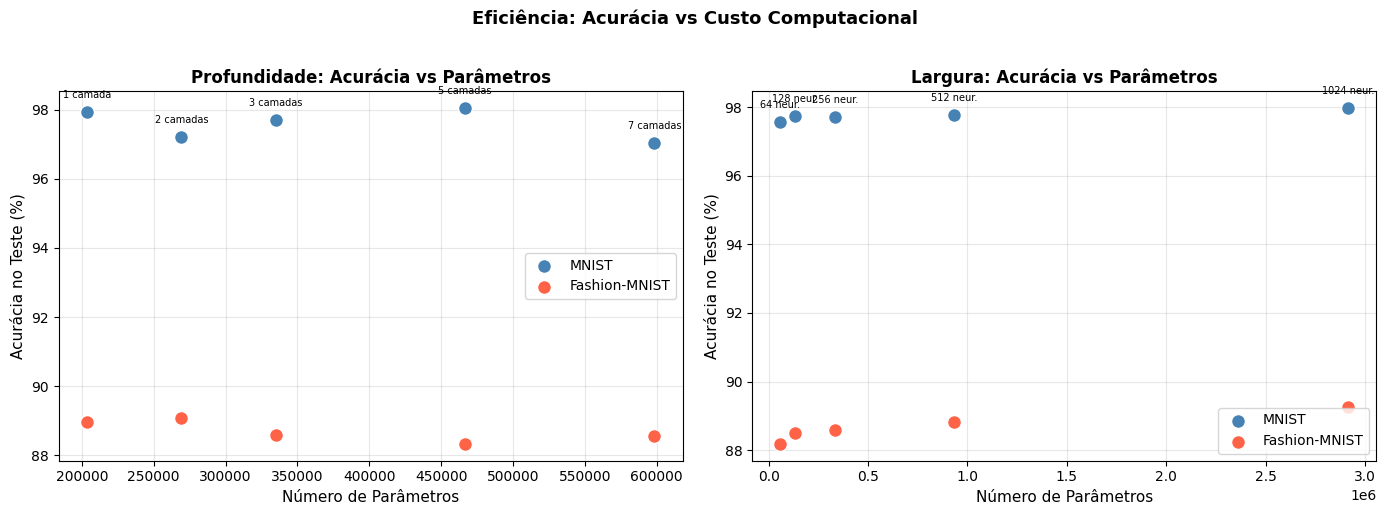

Gráfico salvo: grafico_eficiencia_parametros.png


In [ ]:
# GRÁFICO 5: Acurácia vs Número de Parâmetros

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Profundidade
params_prof = [r['n_params'] for r in resultados_prof_mnist]
acc_m_prof  = [r['acc_teste_final']*100 for r in resultados_prof_mnist]
acc_f_prof  = [r['acc_teste_final']*100 for r in resultados_prof_fmnist]

ax1.scatter(params_prof, acc_m_prof, s=100, color='steelblue', label='MNIST', zorder=5, edgecolors='white')
ax1.scatter(params_prof, acc_f_prof, s=100, color='tomato', label='Fashion-MNIST', zorder=5, edgecolors='white')

for i, nome in enumerate(configs_profundidade.keys()):
    ax1.annotate(nome.split('×')[0].strip(), (params_prof[i], acc_m_prof[i]),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=7)

ax1.set_xlabel('Número de Parâmetros', fontsize=11)
ax1.set_ylabel('Acurácia no Teste (%)', fontsize=11)
ax1.set_title('Profundidade: Acurácia vs Parâmetros', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Largura
params_larg = [r['n_params'] for r in resultados_larg_mnist]
acc_m_larg  = [r['acc_teste_final']*100 for r in resultados_larg_mnist]
acc_f_larg  = [r['acc_teste_final']*100 for r in resultados_larg_fmnist]

ax2.scatter(params_larg, acc_m_larg, s=100, color='steelblue', label='MNIST', zorder=5, edgecolors='white')
ax2.scatter(params_larg, acc_f_larg, s=100, color='tomato', label='Fashion-MNIST', zorder=5, edgecolors='white')

for i, nome in enumerate(configs_largura.keys()):
    n_neur = nome.split('×')[1].strip()
    ax2.annotate(f'{n_neur} neur.', (params_larg[i], acc_m_larg[i]),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=7)

ax2.set_xlabel('Número de Parâmetros', fontsize=11)
ax2.set_ylabel('Acurácia no Teste (%)', fontsize=11)
ax2.set_title('Largura: Acurácia vs Parâmetros', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Eficiência: Acurácia vs Custo Computacional', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('grafico_eficiencia_parametros.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: grafico_eficiencia_parametros.png')

---
## 8. Análise e Discussão dos Resultados

In [ ]:
# ANÁLISE: Gap de generalização (overfitting)

print('=' * 70)
print('ANÁLISE DO GAP DE GENERALIZAÇÃO (acc_treino - acc_teste)')
print('=' * 70)

print('\n--- Série Profundidade ---')
for res_m, res_f in zip(resultados_prof_mnist, resultados_prof_fmnist):
    gap_m = (res_m['acc_treino_final'] - res_m['acc_teste_final']) * 100
    gap_f = (res_f['acc_treino_final'] - res_f['acc_teste_final']) * 100
    nome = res_m['nome'].replace('[MNIST] ', '')
    print(f'  {nome:20s} | Gap MNIST: {gap_m:+.2f}% | Gap F-MNIST: {gap_f:+.2f}%')

print('\n--- Série Largura ---')
for res_m, res_f in zip(resultados_larg_mnist, resultados_larg_fmnist):
    gap_m = (res_m['acc_treino_final'] - res_m['acc_teste_final']) * 100
    gap_f = (res_f['acc_treino_final'] - res_f['acc_teste_final']) * 100
    nome = res_m['nome'].replace('[MNIST] ', '')
    print(f'  {nome:20s} | Gap MNIST: {gap_m:+.2f}% | Gap F-MNIST: {gap_f:+.2f}%')

# ANÁLISE: Melhor configuração

print('\n' + '=' * 70)
print('MELHOR CONFIGURAÇÃO POR DATASET')
print('=' * 70)

# Juntar todos os resultados
todos_mnist  = resultados_prof_mnist + resultados_larg_mnist
todos_fmnist = resultados_prof_fmnist + resultados_larg_fmnist

melhor_mnist  = max(todos_mnist, key=lambda r: r['acc_teste_final'])
melhor_fmnist = max(todos_fmnist, key=lambda r: r['acc_teste_final'])

print(f'\n  MNIST:')
print(f'    Melhor: {melhor_mnist["nome"]}')
print(f'    Acurácia: {melhor_mnist["acc_teste_final"]*100:.2f}%')
print(f'    Parâmetros: {melhor_mnist["n_params"]:,}')

print(f'\n  Fashion-MNIST:')
print(f'    Melhor: {melhor_fmnist["nome"]}')
print(f'    Acurácia: {melhor_fmnist["acc_teste_final"]*100:.2f}%')
print(f'    Parâmetros: {melhor_fmnist["n_params"]:,}')

# ANÁLISE: Retornos decrescentes

print('\n' + '=' * 70)
print('ANÁLISE DE RETORNOS DECRESCENTES')
print('=' * 70)

print('\n--- Profundidade (ganho marginal por camada adicionada) ---')
for i in range(1, len(resultados_prof_mnist)):
    delta_m = (resultados_prof_mnist[i]['acc_teste_final'] - resultados_prof_mnist[i-1]['acc_teste_final']) * 100
    delta_f = (resultados_prof_fmnist[i]['acc_teste_final'] - resultados_prof_fmnist[i-1]['acc_teste_final']) * 100
    nome_ant = list(configs_profundidade.keys())[i-1]
    nome_cur = list(configs_profundidade.keys())[i]
    print(f'  {nome_ant} → {nome_cur}: MNIST {delta_m:+.2f}% | F-MNIST {delta_f:+.2f}%')

print('\n--- Largura (ganho marginal por aumento de neurônios) ---')
for i in range(1, len(resultados_larg_mnist)):
    delta_m = (resultados_larg_mnist[i]['acc_teste_final'] - resultados_larg_mnist[i-1]['acc_teste_final']) * 100
    delta_f = (resultados_larg_fmnist[i]['acc_teste_final'] - resultados_larg_fmnist[i-1]['acc_teste_final']) * 100
    nome_ant = list(configs_largura.keys())[i-1]
    nome_cur = list(configs_largura.keys())[i]
    print(f'  {nome_ant} → {nome_cur}: MNIST {delta_m:+.2f}% | F-MNIST {delta_f:+.2f}%')

ANÁLISE DO GAP DE GENERALIZAÇÃO (acc_treino - acc_teste)

--- Série Profundidade ---
  1 camada × 256       | Gap MNIST: +1.75% | Gap F-MNIST: +4.92%
  2 camadas × 256      | Gap MNIST: +2.22% | Gap F-MNIST: +5.27%
  3 camadas × 256      | Gap MNIST: +1.81% | Gap F-MNIST: +5.09%
  5 camadas × 256      | Gap MNIST: +1.28% | Gap F-MNIST: +4.94%
  7 camadas × 256      | Gap MNIST: +2.24% | Gap F-MNIST: +4.10%

--- Série Largura ---
  3 camadas × 64       | Gap MNIST: +1.67% | Gap F-MNIST: +4.05%
  3 camadas × 128      | Gap MNIST: +1.68% | Gap F-MNIST: +4.86%
  3 camadas × 256      | Gap MNIST: +1.81% | Gap F-MNIST: +5.09%
  3 camadas × 512      | Gap MNIST: +1.65% | Gap F-MNIST: +5.34%
  3 camadas × 1024     | Gap MNIST: +1.43% | Gap F-MNIST: +4.72%

MELHOR CONFIGURAÇÃO POR DATASET

  MNIST:
    Melhor: [MNIST] 5 camadas × 256
    Acurácia: 98.04%
    Parâmetros: 466,698

  Fashion-MNIST:
    Melhor: [F-MNIST] 3 camadas × 1024
    Acurácia: 89.27%
    Parâmetros: 2,913,290

ANÁLISE DE RE

---
## 9. Conclusões e Discussão para a Ficha Comparativa

### Achado Principal
Analisar qual configuração venceu, por quanto, e a explicação técnica. Considerar:

- **Retornos decrescentes de profundidade:** No MNIST (dataset simples), redes rasas já atingem ~98% de acurácia. Adicionar camadas após 2-3 não traz ganho significativo e pode até prejudicar (vanishing gradients sem BatchNorm/ResNet).

- **Largura é mais eficaz que profundidade em certo ponto:** Aumentar neurônios por camada (de 64 para 256-512) geralmente traz ganhos mais consistentes do que adicionar mais camadas.

- **Fashion-MNIST amplifica as diferenças:** Por ser um dataset mais complexo, as diferenças entre configurações ficam mais evidentes.

- **Trade-off parâmetros vs acurácia:** Redes com 1024 neurônios têm milhões de parâmetros mas ganho marginal pequeno vs 256-512.

### Limitações
1. Sem técnicas de regularização (Dropout, BatchNorm) — redes profundas poderiam se beneficiar
2. Apenas ReLU como ativação — outras funções poderiam mitigar vanishing gradients
3. Sem skip connections (ResNet) — redes com 7+ camadas precisariam disso na prática
4. Apenas 15 épocas — redes mais profundas podem precisar de mais tempo para convergir
5. MNIST é um benchmark "saturado" — diferenças são pequenas quando todos atingem ~98%

### Experimento adicional sugerido
Repetir os experimentos de 5 e 7 camadas **com BatchNorm** para verificar se a normalização resolve a degradação de redes profundas sem precisar de skip connections.

### Preparação para Arguição Cruzada

**Pergunta que receberemos do Eixo B:** *"A profundidade afeta a sensibilidade ao learning rate?"*
- Redes mais profundas amplificam gradientes (exploding) ou os atenuam (vanishing), tornando o treino mais sensível ao learning rate
- Com Adam (lr adaptativo), esse efeito é parcialmente mitigado, mas com SGD puro a sensibilidade seria maior

**Pergunta que faremos ao Eixo C:** *"BatchNorm resolve o problema de redes muito profundas sem ResNet?"*